In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                            roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import shap

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = "../outputs/figures"
MODELS_DIR = "../outputs/models"
PROCESSED_DIR = "../data/processed"
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(f"{PROCESSED_DIR}/churn_features_unscaled.csv")
df.shape

(200000, 23)

In [3]:
y = df["churn"].copy()
X = df.drop(columns=["churn"])
print(f"X: {X.shape}|y churn rate:{y.mean():.3f}")

X: (200000, 22)|y churn rate:0.372


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}  churn rate:{y_train.mean():.3f}")
print(f"Test:  {X_test.shape}  churn rate:{y_test.mean():.3f}")

Train: (160000, 22)  churn rate:0.372
Test:  (40000, 22)  churn rate:0.372


In [5]:
numeric_to_scale = ["age", "tenure_months", "avg_order_value", 
                    "total_orders", "last_purchase_days_ago", "support_tickets",
                    "orders_per_month", "total_revenue", "revenue_per_month",
                    "tickets_per_order", "subscription_rank"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_scaled[numeric_to_scale]  = scaler.transform(X_test[numeric_to_scale])

joblib.dump(scaler, f"{MODELS_DIR}/scaler.joblib")

['../outputs/models/scaler.joblib']

In [6]:
# Logistics Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("LogReg trained.")

LogReg trained.


In [7]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
print("RF trained.")

RF trained.


In [8]:
# XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                    tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(X_train, y_train)
print("XGBoost trained.")

scale_pos_weight = 1.69
XGBoost trained.


In [9]:
# Function to calculate metrics
def evaluate(model, X_eval, y_eval, name, threshold=0.5):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
          "model": name,
          "threshold": threshold,
          "accuracy":  accuracy_score(y_eval, pred),
          "precision": precision_score(y_eval, pred),
          "recall":    recall_score(y_eval, pred),
          "f1":        f1_score(y_eval, pred),
          "roc_auc":   roc_auc_score(y_eval, proba)}


In [10]:
results = [evaluate(log_reg, X_test_scaled, y_test, "LogisticRegression"),
           evaluate(rf, X_test, y_test, "RandomForest"),
           evaluate(xgb, X_test, y_test, "XGBoost"),]
results_df = pd.DataFrame(results).round(3)
results_df

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.5,0.628,0.500,0.638,0.560,0.682
1,RandomForest,0.5,0.651,0.557,0.309,0.398,0.664
2,XGBoost,0.5,0.620,0.492,0.647,0.559,0.676


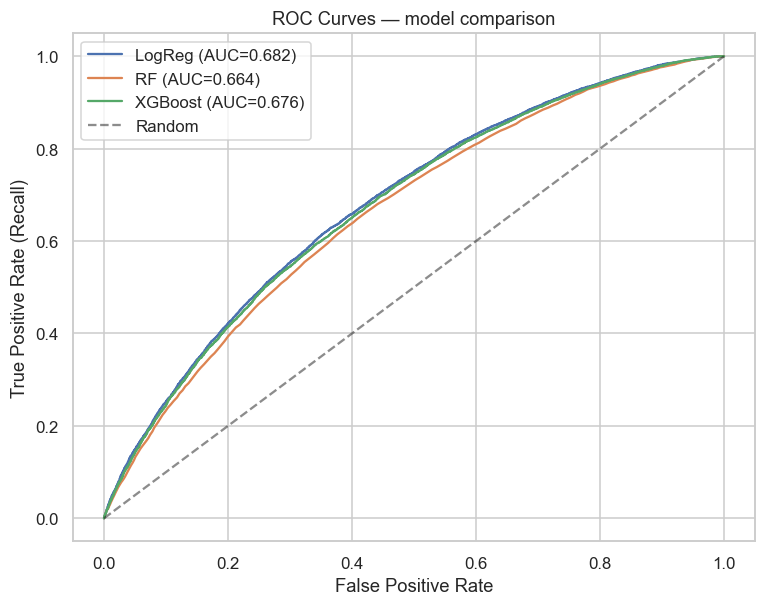

In [11]:
# ROC Curve
plt.figure(figsize=(8, 6))
for model, X_eval, name in [(log_reg, X_test_scaled, "LogReg"),(rf, X_test, "RF"),
      (xgb, X_test, "XGBoost"), ]:
    proba = model.predict_proba(X_eval)[:, 1]
    fpr,tpr,_ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5,label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — model comparison")
plt.legend()
plt.savefig(f"{FIG_DIR}/roc_comparison.png",bbox_inches="tight")
plt.show()

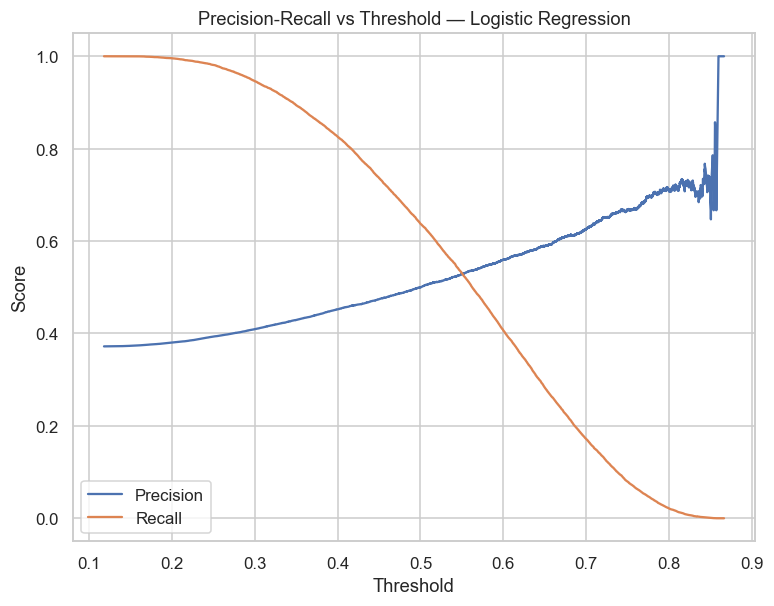

In [12]:
best_model = log_reg
best_X_test = X_test_scaled
best_name = "Logistic Regression"

proba = best_model.predict_proba(best_X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1],label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision-Recall vs Threshold — {best_name}")
plt.legend()
plt.grid(True)
plt.savefig(f"{FIG_DIR}/pr_curve.png",bbox_inches="tight")
plt.show()

In [13]:
# Find the optimized threshold
target_precision = 0.48
valid_idx = np.where(precisions[:-1] >= target_precision)[0]
chosen_idx = valid_idx[np.argmin(thresholds[valid_idx])] if len(valid_idx) else np.argmax(recalls[:-1])
chosen_threshold = thresholds[chosen_idx]

print(f"Chosen threshold: {chosen_threshold:.3f}")
print(f"  Precision: {precisions[chosen_idx]:.3f}")
print(f"  Recall:    {recalls[chosen_idx]:.3f}")

Chosen threshold: 0.462
  Precision: 0.480
  Recall:    0.715


In [14]:
#re-evaluate at tuned threshold and comparison final
tuned_result = evaluate(best_model, best_X_test, y_test, f"{best_name} (tuned)",
                        threshold=chosen_threshold)
final_df = pd.concat([results_df, pd.DataFrame([tuned_result]).round(3)], ignore_index=True)
final_df

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.500,0.628,0.500,0.638,0.560,0.682
1,RandomForest,0.500,0.651,0.557,0.309,0.398,0.664
2,XGBoost,0.500,0.620,0.492,0.647,0.559,0.676
3,Logistic Regression (tuned),0.462,0.606,0.480,0.715,0.574,0.682


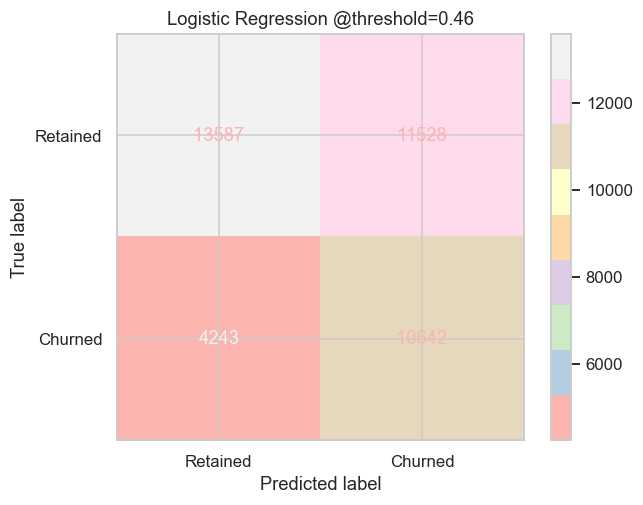

In [15]:
# confusion matrix
proba = best_model.predict_proba(best_X_test)[:, 1]
pred_tuned = (proba >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"])
disp.plot(cmap="Pastel1", values_format="d")
plt.title(f"{best_name} @threshold={chosen_threshold:.2f}")
plt.savefig(f"{FIG_DIR}/confusion_matrix_tuned.png",bbox_inches="tight")
plt.show()

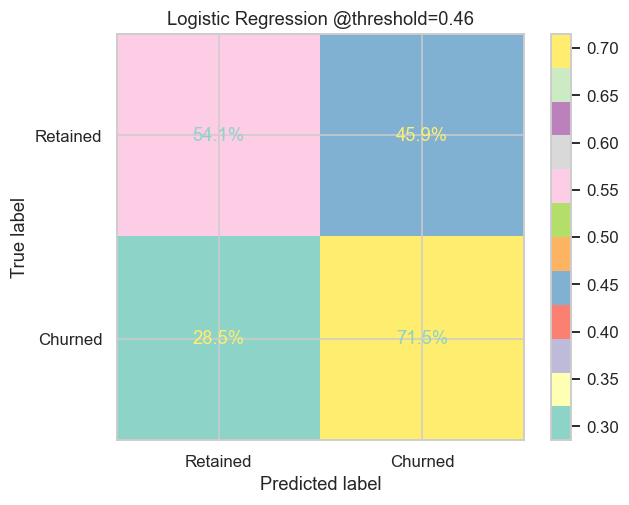

In [16]:
# confusion matrix (% version)
proba = best_model.predict_proba(best_X_test)[:, 1]
pred_tuned = (proba >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, pred_tuned, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"])
disp.plot(cmap="Set3", values_format=".1%")
plt.title(f"{best_name} @threshold={chosen_threshold:.2f}")
plt.savefig(f"{FIG_DIR}/confusion_matrix_tuned.png",bbox_inches="tight")
plt.show()

In [17]:
joblib.dump(best_model,f"{MODELS_DIR}/{best_name.lower()}_churn.joblib")

with open(f"{MODELS_DIR}/threshold.txt", "w") as f:
    f.write(f"{chosen_threshold:.4f}\n")

print(f"Saved: {best_name.lower()}_churn.joblib and threshold.txt")

Saved: logistic regression_churn.joblib and threshold.txt


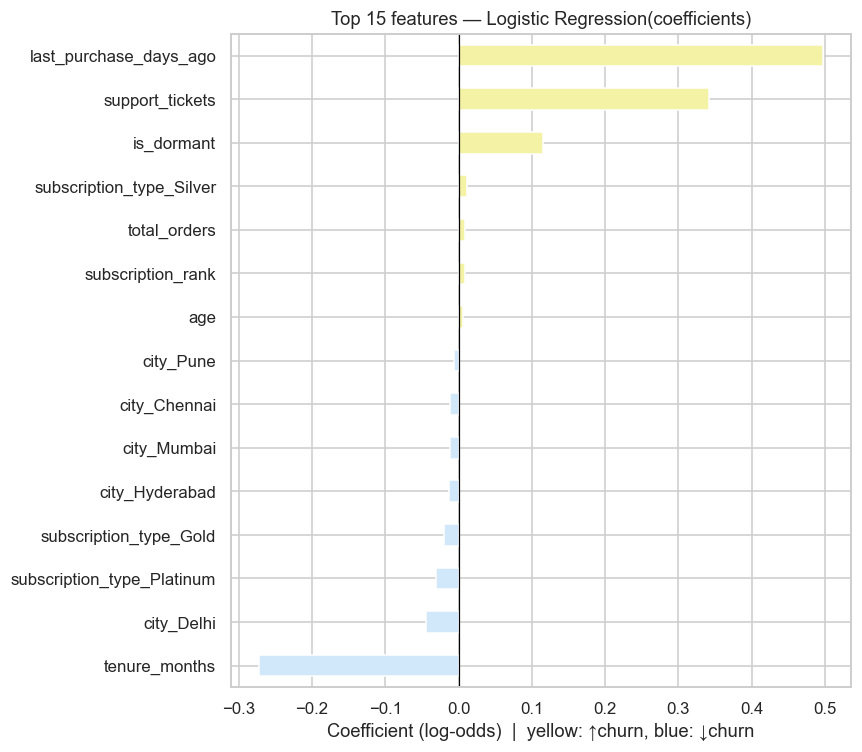

In [18]:
# Tree-based feature importance
coefs = pd.Series(best_model.coef_[0],index=X_train.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
top = top.sort_values()

plt.figure(figsize=(8, 7))
colors = ["#F4F2A4" if c > 0 else "#D1E7FA" for c in top] 
top.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Top 15 features — {best_name}(coefficients)")
plt.xlabel("Coefficient (log-odds)  |  yellow: ↑churn, blue: ↓churn")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_importance.png",bbox_inches="tight")
plt.show()

In [19]:
# SHAP
sample_size = 5000
X_sample = X_test_scaled.sample(sample_size,random_state=42) 

explainer = shap.LinearExplainer(best_model, X_train_scaled)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (5000, 22)


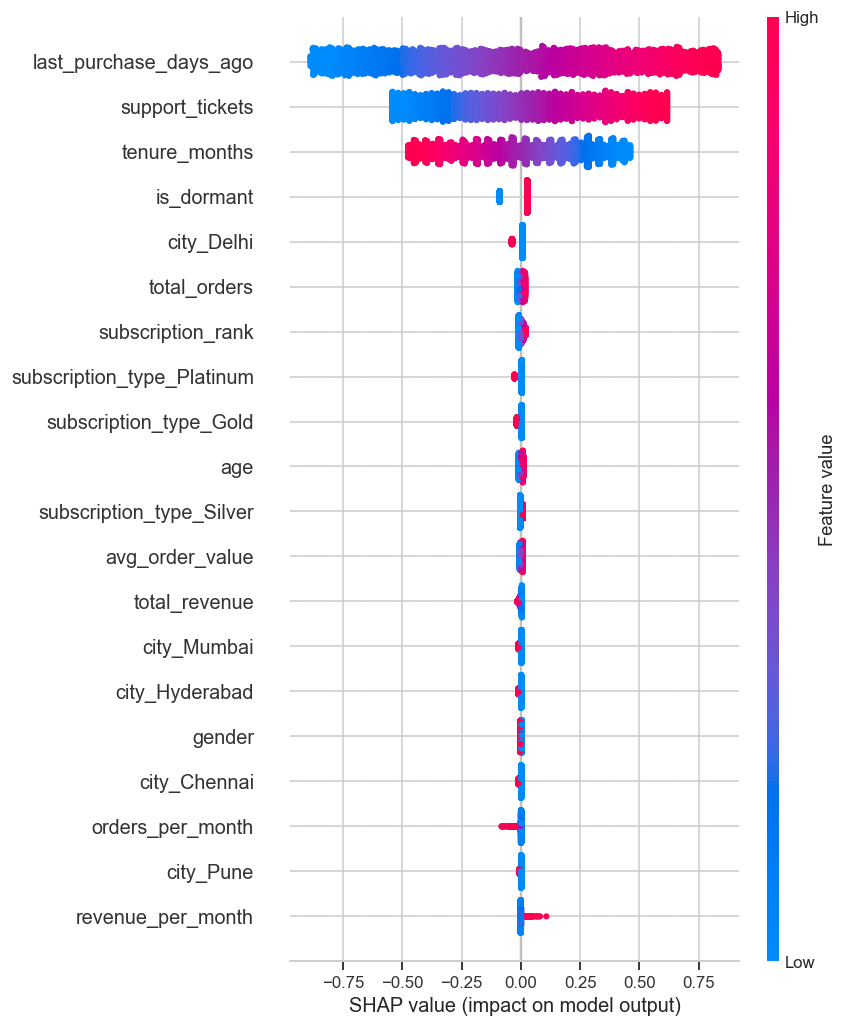

In [20]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig(f"{FIG_DIR}/shap_summary.png",bbox_inches="tight")
plt.show()

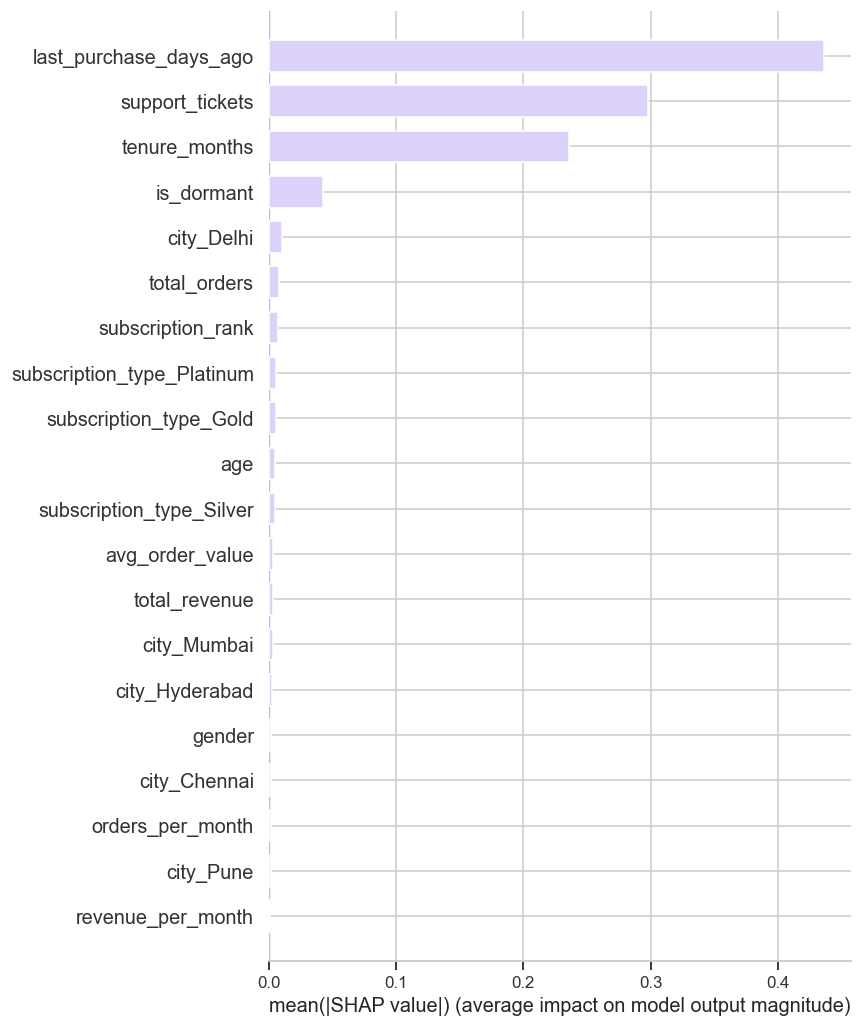

In [21]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, color="#DCD1FA")
plt.savefig(f"{FIG_DIR}/shap_bar.png", bbox_inches="tight")
plt.show()

In [22]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({"feature": X_sample.columns, 
                        "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False)

shap_df.to_csv(f"{PROCESSED_DIR}/shap_importance.csv", index=False)
shap_df.head(10)

,feature,mean_abs_shap
5,last_purchase_days_ago,0.435680
6,support_tickets,0.297539
2,tenure_months,0.235475
21,is_dormant,0.042468
9,city_Delhi,0.010905
4,total_orders,0.008271
7,subscription_rank,0.007474
15,subscription_type_Platinum,0.005910
14,subscription_type_Gold,0.005591
0,age,0.005030


In [23]:
# Score full test set for dashboard
test_proba = best_model.predict_proba(X_test)[:, 1]

dashboard_df = X_test.copy()
dashboard_df["churn_actual"] = y_test.values
dashboard_df["churn_probability"] = test_proba
dashboard_df["risk_band"] = pd.cut(test_proba,
                                   bins=[-0.01, 0.30, 0.60, 1.01],
                                   labels=["Low", "Medium", "High"])

dashboard_df.to_csv(f"{PROCESSED_DIR}/churn_scored.csv", index=False)
print(f"Saved: churn_scored.csv({dashboard_df.shape})")
dashboard_df[["churn_actual", "churn_probability","risk_band"]].head()

Saved: churn_scored.csv((40000, 25))


,churn_actual,churn_probability,risk_band
13581,0,0.0,Low
168704,1,0.0,Low
108554,1,0.0,Low
79499,0,0.0,Low
33296,1,0.0,Low


In [24]:
# Join scored test set with raw to get the city + subscription_type as string
raw = pd.read_csv("../data/raw/ecommerce_customer_churn_large.csv")
scored = pd.read_csv("../data/processed/churn_scored.csv")

In [25]:
# Take raws test set (same index as X_test)
dashboard = raw.loc[X_test.index].reset_index(drop=True).copy()
dashboard["churn_probability"] = scored["churn_probability"].values
dashboard["churn_actual"]      = scored["churn_actual"].values

In [27]:
# Re-bin risk band
dashboard["risk_band"] = pd.cut(dashboard["churn_probability"], bins=[-0.01, 0.20,0.50, 1.01],
                                labels=["Low", "Medium", "High"])

dashboard.to_csv("../data/processed/dashboard.csv",index=False)
dashboard["risk_band"].value_counts()

risk_band
Low       38394
High       1598
Medium        8
Name: count, dtype: int64